Trying to figure out how to have all the particles informations at every element of the LSS2

In [53]:
import pybt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')


plt.ion()

In [54]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx
import matplotlib as mpl
import matplotlib.patches as patches
import re

import septa

This SeptumInteraction class is made for the interaction of the particles with the septum.

In [55]:
class SeptumInteraction:
    def __init__(self, blade_position: float = 68e-3, thickness:float = 0.3e-3, kick:float = 1e-3, angle: float=-1.5, width:float = 0, aperture = 1e-2) -> None:
        self.blade_position = blade_position
        self.thickness = thickness
        self.kick = kick
        self.angle = angle
        self.width = width
        self.aperture = aperture
        pass

    def interact(self, particles: xp.Particles) -> t.Optional[t.Dict]:
        n_part = particles._num_active_particles

        # kick the particles beyond the blade and under the cathode
        if self.kick != 0:
            # only particles with this condition get a kick
            mask_kick = (particles.x[:n_part] > (self.blade_position + self.thickness)) & \
                        (particles.x[:n_part] < self.blade_position + self.thickness + self.aperture) & \
                        (particles.state[:n_part] == 1)
            particles.px[:n_part] += np.where(mask_kick, self.kick, 0)
        
        # particles with this condition are eliminated
        mask_eliminate = (particles.x[:n_part] < (self.blade_position + self.thickness)) | \
                        (particles.x[:n_part] > self.blade_position + self.thickness + self.aperture) & \
                        (particles.state[:n_part] == 1)
        
        particles.state[:n_part] = np.where(mask_eliminate, -1, particles.state[:n_part])

        return None

Functions to install the ZS, MST and MSE in the line.

In [56]:
def install_iterated_ZSsepta(line, install_zs=True, subdivision_number = 50):
    septa_names_with_apertures = []

    if install_zs:
        septum_names = septa.septum_namesZS
        subdivision_number = subdivision_number  
        width = septa.widthZSelements  # Width of the entire element
        heightZS = septa.heightZSelements
        blade_positionsZS = septa.blade_positionsZS
        aperture = septa.apertureZS
        
        # Installing monitors to measure the particles positions at their passage
        monitors = []
        
        for septum_name in septum_names:  # Cycle for every element
            n = septum_names.index(septum_name)
            # Assigning thickness based on the septum name
            if septum_name in ["zs.21633", "zs.21639"]:
                thickness = 0.6e-4
            else:
                thickness = 1e-4
            
            for i in range(subdivision_number):  # Cycle for subdivision
                # Scalo verso il basso la blade_position per ogni suddivisione
                blade_position = blade_positionsZS[n] - i * heightZS / subdivision_number
                index_of_suddivision = str(i)
                
                # Calculate the position along the line (s)
                at_s_position = line.get_s_position(septum_name) + i * (width / subdivision_number)
            
                # Inserting the anode
                zs = xt.BeamInteraction(
                    length = 0.0,
                    interaction_process = SeptumInteraction(
                        blade_position = blade_position,
                        thickness = thickness,
                        kick = septa.kickZS / (subdivision_number),
                        angle = -1.5,
                        width = width / subdivision_number,  
                        aperture = aperture
                    ),
                )
                line.insert_element(
                    name = septum_name + "_" + index_of_suddivision + ".sep",
                    element = zs,
                    at_s = at_s_position  
                )
                septa_names_with_apertures.append(septum_name + "_" + index_of_suddivision + ".sep")
                
                
                # Installing monitors for every sliced element
                monitor = xt.BeamSizeMonitor(stop_at_turn=1)
                line.insert_element(
                    name = septum_name + "_" + index_of_suddivision +".monitor",
                    element = monitor,
                    at_s = at_s_position  # inserting the monitors at the desired position
                )
                monitors.append(monitor) #CHECK ONE_TURN_MONITOR IN TRACKING
                
                            

        #Installing monitor at the ZS end to obtatin the beam's envelop outside the ZS
        last_septum_name = septum_names[-1]
        last_s_position = line.get_s_position(last_septum_name) + width # Position after the last septum
        exit_monitor = xt.BeamSizeMonitor(stop_at_turn=1)
        
        line.insert_element(
            name = "ZS_exit.monitor",
            element = exit_monitor,
            at_s = last_s_position  # Insert monitor after the last septum element
        )
        
        #Installing monitor outside the MST to obtatin the beam's envelop outside the MST
        outside_monitors_numberZS = 8
        for i in range(outside_monitors_numberZS):
            outside_monitor_number = str(i)
            last_septum_name = septum_names[-1]
            last_s_position = line.get_s_position(last_septum_name) + width * i * 1.2  # Position after the last septum
            outside_monitor = xt.BeamSizeMonitor(stop_at_turn = 1)
            
            line.insert_element(
                name = "ZS_outside_" + outside_monitor_number + ".monitor",
                element = outside_monitor,
                at_s = last_s_position  # Insert monitor after the last septum element for i times
            )
            monitors.append(outside_monitor) 
        
        #Installing monitor at the entrance
        first_s_position = line.get_s_position('zs.21633_0.monitor') - width/subdivision_number * 0.99 # Position after the last septum
        monitor = xt.BeamSizeMonitor(stop_at_turn=1)
        
        line.insert_element(
            name = "ZSEntry.monitor",
            element = monitor,
            at_s = first_s_position  # Insert monitor after the last septum element
        )        
                
    return septa_names_with_apertures


In [57]:
def install_iterated_MSTsepta(line, install_mst=True, subdivision_number = 50):
    septa_names_with_apertures = []

    subdivision_number = subdivision_number  
    
    if install_mst:
        
        # Defining variable for the MST elements
        blade_positionTPST =septa.blade_positionTPST
        widthTPST = septa.widthMSTelements  # Width of the entire element
        heightTPST = septa.heightTPST   
        apertureTPST = septa.apertureTPST
        thicknessTPST = septa.thicknessTPST
        kickTPST = septa.kickTPST
        
        # Defining variable for the MST elements
        septum_names = septa.septum_namesMST
        widthMST = septa.widthMSTelements  # Width of the entire element
        heightMST = septa.heightMSTelements
        blade_positionsMST = septa.blade_positionsMST
        apertureMST = septa.apertureMST
        thicknessMST = septa.thicknessMST
        kickMST = septa.kickMST
        
        # Installing monitors to measure the particles positions at their passage
        monitors = []
        
        #INSTALLING THE FIRST ELEMENT TPST WHICH IS ONLY A MASK
        for i in range(subdivision_number):
            index_of_suddivisionTPST = str(i)
            
            blade_positionTPSTsliced = blade_positionTPST + i * heightTPST / subdivision_number
            at_s_positionTPST = line.get_s_position("tpst.21760_entry") + i * (widthTPST / subdivision_number)
                
                
            tpst = xt.BeamInteraction(
                length=0.0,
                interaction_process=SeptumInteraction(
                    blade_position = blade_positionTPSTsliced, thickness = thicknessTPST, kick = kickTPST, width = widthTPST / subdivision_number, aperture = apertureTPST),
                )
            line.insert_element(name = "tpst.21760_"+ index_of_suddivisionTPST + ".sep", element = tpst, at_s = at_s_positionTPST) 
            septa_names_with_apertures.append("tpst.21760" + ".sep")

            # Installing monitors for every sliced element
            monitorTPST = xt.BeamSizeMonitor(stop_at_turn=1)
            line.insert_element(
                name = "tpst.21760_"+ index_of_suddivisionTPST +".monitor",
                element = monitorTPST, at_s = at_s_positionTPST  # inserting the monitors at the desired position
                )
            monitors.append(monitorTPST) #CHECK ONE_TURN_MONITOR IN TRACKING
                

                
        # INSTALLING MST
        for septum_name in septum_names:  # Cycle for every element
            n = septum_names.index(septum_name)
            
            for i in range(subdivision_number):  # Cycle for subdivision
                index_of_suddivision = str(i)
                
                # Scaling down for every slice 
                blade_positionMST = blade_positionsMST[n] + i * heightMST / subdivision_number
                
                # Calculate the position along the line (s)
                at_s_position = line.get_s_position(septum_name) + i * (widthMST / subdivision_number)

                # Inserting the anode
                zs = xt.BeamInteraction(
                    length = 0.0,
                    interaction_process = SeptumInteraction(
                        blade_position = blade_positionMST,
                        thickness = thicknessMST,
                        kick = kickMST / subdivision_number,
                        angle = -1.5,
                        width = widthMST / subdivision_number,  
                        aperture = apertureMST
                    ),
                )
                line.insert_element(
                    name = septum_name + "_" + index_of_suddivision + ".sep",
                    element = zs,
                    at_s = at_s_position  
                )
                septa_names_with_apertures.append(septum_name + "_" + index_of_suddivision + ".sep")
                
                
                # Installing monitors for every sliced element
                monitor = xt.BeamSizeMonitor(stop_at_turn=1)
                line.insert_element(
                    name = septum_name + "_" + index_of_suddivision +".monitor",
                    element = monitor,
                    at_s = at_s_position  # inserting the monitors at the desired position
                )
                monitors.append(monitor) #CHECK ONE_TURN_MONITOR IN TRACKING
                
                            

        #Installing monitor at the MST end to obtatin the beam's envelop outside the MST
        last_septum_name = septum_names[-1]
        last_s_position = line.get_s_position(last_septum_name) + widthMST # Position after the last septum
        exit_monitor = xt.BeamSizeMonitor(stop_at_turn=1)
        
        line.insert_element(
            name = "MST_exit.monitor",
            element = exit_monitor,
            at_s = last_s_position  # Insert monitor after the last septum element
        )
        
        #Installing monitor outside the MST to obtatin the beam's envelop outside the MST
        last_septum_name = septum_names[-1]
        last_s_position = line.get_s_position(last_septum_name) + widthMST * 2  # Position after the last septum
        outside_monitor = xt.BeamSizeMonitor(stop_at_turn = 1)
        
        line.insert_element(
            name = "MST_outside.monitor",
            element = outside_monitor,
            at_s = last_s_position  # Insert monitor after the last septum element
        )

        monitors.append(exit_monitor)  
        
        #Installing monitor outside the MST to obtatin the beam's envelop outside the MST
        outside_monitors_numberMST = 4
        for i in range(outside_monitors_numberMST):
            outside_monitor_number = str(i)
            last_septum_name = septum_names[-1]
            last_s_position = line.get_s_position(last_septum_name) + widthMST * i * 1.2  # Position after the last septum
            outside_monitor = xt.BeamSizeMonitor(stop_at_turn = 1)
            
            line.insert_element(
                name = "MST_outside_" + outside_monitor_number + ".monitor",
                element = outside_monitor,
                at_s = last_s_position  # Insert monitor after the last septum element for i times
            )
            monitors.append(outside_monitor) 
        
                
    return septa_names_with_apertures


In [58]:
def install_iterated_MSEsepta(line, install_mse=True, subdivision_number = 50):
    septa_names_with_apertures = []

    if install_mse:
        septum_names = septa.septum_namesMSE
        subdivision_number = subdivision_number  
        width = septa.widthMSEelements # Width of the entire element
        blade_positionsMSEentrance = septa.blade_positionsMSEentrance
        blade_positionMSEexits = septa.blade_positionsMSEexits
        aperture = septa.apertureMSE
        thicknessMSE = septa.thicknessMSE
        kick = septa.kickMSE
        
        # Installing monitors to measure the particles positions at their passage
        monitors = []
        
        for septum_name in septum_names:  # Cycle for every element
            n = septum_names.index(septum_name)
            heightMSE = blade_positionsMSEentrance[n] - blade_positionMSEexits[n]    
            
            for i in range(subdivision_number):  # Cycle for subdivision
                index_of_suddivision = str(i)
                # Scaling the slices
                blade_position = blade_positionsMSEentrance[n] - i * heightMSE / subdivision_number
                at_s_position = line.get_s_position(septum_name) + i * (width / subdivision_number)
            
                # Inserting the anode
                MSE = xt.BeamInteraction(
                    length = 0.0,
                    interaction_process = SeptumInteraction(
                        blade_position = blade_position,
                        thickness = thicknessMSE,
                        kick = kick / (subdivision_number),
                        angle = -1.5,
                        width = width / subdivision_number,  
                        aperture = aperture
                    ),
                )
                line.insert_element(
                    name = septum_name + "_" + index_of_suddivision + ".sep",
                    element = MSE,
                    at_s = at_s_position  
                )
                septa_names_with_apertures.append(septum_name + "_" + index_of_suddivision + ".sep")
                
                
                # Installing monitors for every sliced element
                monitor = xt.BeamSizeMonitor(stop_at_turn=1)
                line.insert_element(
                    name = septum_name + "_" + index_of_suddivision +".monitor",
                    element = monitor,
                    at_s = at_s_position  # inserting the monitors at the desired position
                )
                monitors.append(monitor) #CHECK ONE_TURN_MONITOR IN TRACKING
                
                            

        #Installing monitor at the MSE end to obtatin the beam's envelop outside the MSE
        last_septum_name = septum_names[-1]
        last_s_position = line.get_s_position(last_septum_name) + width # Position after the last septum
        exit_monitor = xt.BeamSizeMonitor(stop_at_turn=1)
        
        line.insert_element(
            name = "MSE_exit.monitor",
            element = exit_monitor,
            at_s = last_s_position  # Insert monitor after the last septum element
        )
        
        #Installing monitor outside the MST to obtatin the beam's envelop outside the MST
        outside_monitors_numberMSE = 8
        for i in range(outside_monitors_numberMSE):
            outside_monitor_number = str(i)
            last_septum_name = septum_names[-1]
            last_s_position = line.get_s_position(last_septum_name) + width * i * 1.5  # Position after the last septum
            outside_monitor = xt.BeamSizeMonitor(stop_at_turn = 1)
            
            line.insert_element(
                name = "MSE_outside_" + outside_monitor_number + ".monitor",
                element = outside_monitor,
                at_s = last_s_position  # Insert monitor after the last septum element for i times
            )
            monitors.append(outside_monitor) 
                
                
    return septa_names_with_apertures


In [59]:
def draw_sep_elements(ax, line):
    # getting the elements from the line after installing them with install_septa function
    septa_elements = [el for el in line.element_dict.keys() if ".sep" in el]
    
    for septum_name in septa_elements:
        element = line[septum_name]
        interaction_process = element.interaction_process

        # Getting the informations
        blade_position = interaction_process.blade_position
        thickness = interaction_process.thickness
        width = interaction_process.width
        s_position = line.get_table()['s', septum_name]
        aperture = interaction_process.aperture
        
        # Printing the element's informations for a check
        print(f"Element: {septum_name}, s_position: {s_position}, blade_position: {blade_position}, thickness: {thickness}")
        
        if "_0.sep" in septum_name:
            # Writing the name of the element at the s_position
            ax.text(s_position, ax.get_ylim()[1], septum_name, ha='center', va='bottom', rotation=90, fontsize=10, color='blue')

        # . Disegna un rettangolo nero verticale per la lama
        ax.add_patch(plt.Rectangle((s_position, blade_position), width, thickness , color='black'))
        
        # . Disegna un rettangolo nero verticale per la l'anodo
        ax.add_patch(plt.Rectangle((s_position, blade_position + thickness + aperture), width, ax.get_ylim()[1], color='black'))
        
        
    # Settaggi degli assi
    ax.set_xlabel('s (m)')
    ax.set_ylabel('x (m)')
    ax.legend(loc='lower right')

    return ax

In [60]:
def get_beam(line, twiss):
    out = line.record_last_track.to_dict()
    out = pd.DataFrame(out['data'])
    elements = line.get_table().to_pandas()
    elements['at_element'] = elements.index
    out = out.join(elements, on='at_element', rsuffix='_elem', how='inner')
    #out = out.join(twiss.loc[:, ['tilt']], on='name', rsuffix='_twiss', how='inner')
    out.index = out['name']
    
    cols = ['x', 'px', 'y', 'py', 'zeta', 'delta', 'state']
    #out_selected = untilt(out.loc[:, cols + ['s', 'tilt', 'at_element']])
    #out_selected = out.loc[:, cols + ['s', 'tilt', 'at_element', 'particle_id']]
    out_selected = out.loc[:, cols + ['s', 'at_element', 'particle_id']]
    
    return out_selected

In [61]:
p = septa.p
momentum = p
Brho = septa.Brho

N_EX = septa.N_EX
N_EY = septa.N_EY
DPP = septa.DPP

septum_aperture_position = septa.septum_aperture_position

ZSentrances = septa.ZSentrances
ZSexits = septa.ZSexits

MSTentrances = septa.MSTentrances
MSTexits = septa.MSTexits

In [62]:
# Define slicing strategies for thick elements, if needed
Strategy = xt.slicing.Strategy
Teapot = xt.slicing.Teapot

line = xt.Line.from_json("./sps_with_extraction_sliced_quads.json")

Loading line from dict:   0%|          | 0/9960 [00:00<?, ?it/s]

Done loading line from dict.           


In [63]:
# Define a rectangular limit for the septum aperture
septum = xt.LimitRect(min_x=-1., max_x=septum_aperture_position, # CHECK IF IT IS INVERTED MIN_X AND MAX_X
                      min_y=-1., max_y=1.)  # Rectangle defined by min/max values

# Insert the defined septum element into the line at a specified index
line.insert_element(name="zs_aperture", element=septum, index='zs.21633_entry')
line.cycle("zs_aperture", inplace=True)  # Cycle the line to ensure proper setup
line.build_tracker()  # Build the tracker for the simulation


# Switch on extraction bump
line.vv["extr_bump_knob"] = 0.88

# Extraction tunes
opt = line.match(solve=False,
    vary=[
        xt.VaryList(['kqf', 'kqd'], step=1e-7),   # Varying quadrupole focal strengths
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4),   # Varying phase values
    ],
    targets=[
        xt.TargetSet(qx=26.666666666, qy=26.58, tol=1e-5),    # Desired target tunes
        xt.TargetSet(dqx=-1 * 26., dqy=0.47 * 26., tol=1e-3),    # Desired dispersion values
    ])

opt.solve()  # Solve the matching problem to find optimal parameters

# Switch on extraction sextupoles
line.vv["sps_on_extraction"] = 1.0


Matching: model call n. 12               



In [64]:
# Convert the line setup to a DataFrame for easier analysis
line_df = line.to_pandas()

line.vars.get_table()  # Retrieve variable table for inspection

# Specify number of particles for the simulation
n_part = 200 

# Generate normalized 2D Gaussian distributions for particle coordinates and momenta
x_norm, px_norm = xp.generate_2D_gaussian(num_particles=n_part)
y_norm, py_norm = xp.generate_2D_gaussian(num_particles=n_part)

# Initialize longitudinal coordinate and momentum spread
zeta = 0.0
dpp = np.random.rand(n_part) * DPP

# Build the particle distribution based on the generated parameters
particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,   # Normalized emittance in x direction
    nemitt_y=N_EY,   # Normalized emittance in y direction
)

In [65]:

line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu())
line.reset_s_at_end_turn = False
num_turns = 100
ele_stop = line.element_names.index('zs.21633_entry')

line.track(
    particles,
    ele_stop = ele_stop,
    num_turns = num_turns,
    turn_by_turn_monitor='ONE_TURN_EBE',
    time=True,
)
#line.time_last_track
rec = line.record_last_track
twissDFinitial = line.twiss().to_pandas()

In [79]:
dfInitial = get_beam(line, twissDFinitial)

#Getting the minimum  and maximum values of the beam
x_minInitial = dfInitial.groupby('s').x.min()
print("The minmum values at the locations are:")
print(x_minInitial)


x_maxInitial = dfInitial.groupby('s').x.max()
print("The maximum values at the locations are:")
print(x_maxInitial)

dfInitial.index.drop_duplicates()

dfCirculating = get_beam(line, twissDFinitial)

#Getting the minimum  and maximum values of the beam
x_min = dfCirculating.groupby('s').x.min()
print("The minmum values of the circulating beam at the locations(s) are:")
print(x_min)


x_max = dfCirculating.groupby('s').x.max()
print("The maximum values of the circulating at the locations(s) are:")
print(x_max)

The minmum values at the locations are:
s
0.0000       0.041364
1.5650       0.039932
3.1300       0.038500
3.9100       0.037786
5.4750       0.036353
               ...   
6907.5702    0.043835
6908.3284    0.043895
6909.0866    0.043577
6909.8448    0.042883
6911.5038    0.041365
Name: x, Length: 4154, dtype: float64
The maximum values at the locations are:
s
0.0000       0.041373
1.5650       0.039941
3.1300       0.038508
3.9100       0.037794
5.4750       0.036362
               ...   
6907.5702    0.043844
6908.3284    0.043904
6909.0866    0.043585
6909.8448    0.042891
6911.5038    0.041373
Name: x, Length: 4154, dtype: float64
The minmum values of the circulating beam at the locations(s) are:
s
0.0000       0.041364
1.5650       0.039932
3.1300       0.038500
3.9100       0.037786
5.4750       0.036353
               ...   
6907.5702    0.043835
6908.3284    0.043895
6909.0866    0.043577
6909.8448    0.042883
6911.5038    0.041365
Name: x, Length: 4154, dtype: float64
The ma

In the next I am creating a copy of the extracted particles.

In [67]:
# Convert to DataFrame pandas
particles_df = particles.to_pandas()

aperture_acceptance = 2e-3

# KEEP THE ORIGINAL PARTICLES WITHOUT MAKING A COPY

# Selecting extracted particles
particles_extracted_df = particles_df[particles_df['x']  > septum_aperture_position - aperture_acceptance]
#particle_extracted_df = particles_df['state'== 0]  

# number of extracted particles
n_part_extracted = len(particles_extracted_df)
print(f"Number of extracted particles: {n_part_extracted}")

if n_part_extracted > 0:
    particlesExtracted = xt.Particles(
        x=np.array(particles_extracted_df['x']),
        px=np.array(particles_extracted_df['px']),
        y=np.array(particles_extracted_df['y']),
        py=np.array(particles_extracted_df['py']),
        zeta=np.array(particles_extracted_df['zeta']),
        delta=np.array(particles_extracted_df['delta']),
        particle_id=np.array(particles_extracted_df['particle_id']),
    )

Number of extracted particles: 24


Plotting the phase space of the extracted particles

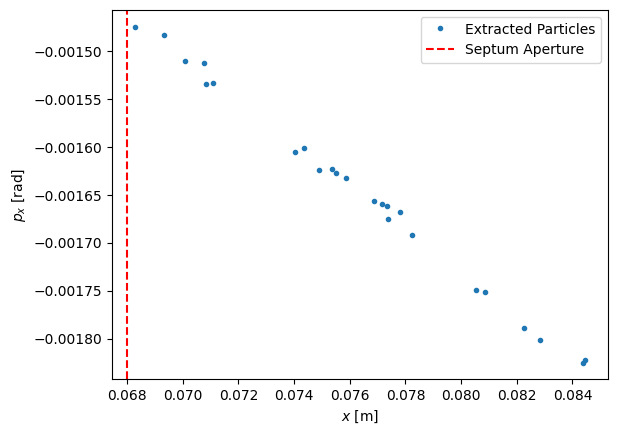

In [68]:
plt.figure(2)
plt.plot(particlesExtracted.x, particlesExtracted.px, ".", label='Extracted Particles')
plt.axvline(septum_aperture_position, color="red", ls="--", label='Septum Aperture')
plt.xlabel(r"$x$ [m]")
plt.ylabel(r"$p_x$ [rad]")
plt.legend()

plt.show()

In the next cell I am creating a new line for a easier analysis of the extracted particles. In this line I install all the septum elements that in the previous line were not installed. The reason of this is that the SeptumInteraction class would eliminate the particles outside the aperture. 

In the near future I will implement a single line with a different SeptumInteraction class that will not eliminate the particles outside the aperture so that it will be possible to simulate a realistic spill.

The idea is to create a SeptumeInteraction that eliminates only the particles that hit the blades.

In [69]:
LSS2 = xt.Line.from_json("./sps_with_extraction_sliced_quads.json")

subdivision_number = 10

LSS2.discard_tracker()

monitorsZS = install_iterated_ZSsepta(LSS2, subdivision_number = subdivision_number)
monitorsMST = install_iterated_MSTsepta(LSS2, subdivision_number = subdivision_number)
monitorsMSE = install_iterated_MSEsepta(LSS2, subdivision_number = subdivision_number)
#LSS2.cycle("zs.21633_0.monitor")
LSS2.cycle("zs.21633_entry")

particlesExtractedInitial = particlesExtracted.copy()


Loading line from dict:   0%|          | 0/9960 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/9962 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/9965 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/9968 [00:00<?, ?it/s]

...

Slicing line:   0%|          | 0/10405 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/10407 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/10409 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/10411 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/10413 [00:00<?, ?it/s]

In [70]:
LSS2.discard_tracker()
LSS2.build_tracker(_context=xo.ContextCpu())



ele_startZS = LSS2.element_names.index('zs.21633_entry')
#ele_stop = LSS2.element_names.index('zs.21676_'  + str(subdivision_number - 1) + '.monitor') + 5
ele_stop = LSS2.element_names.index('mse.21872_'  + str(subdivision_number - 1) + '.monitor') + 100


LSS2.track(
    particlesExtracted,
    ele_start = ele_startZS,
    ele_stop = ele_stop,
    num_turns = 1,
    turn_by_turn_monitor = 'ONE_TURN_EBE'
    )
out = LSS2.record_last_track
twissDF = LSS2.twiss().to_pandas()


The line has collective elements.
In the twiss computation collective elements are replaced by drifts


In [71]:
df = get_beam(LSS2, twissDF)

#Getting the minimum  and maximum values of the beam
x_min = df.groupby('s').x.min()
print("The minmum values at the locations are:")
print(x_min)


x_max = df.groupby('s').x.max()
print("The maximum values at the locations are:")
print(x_max)

The minmum values at the locations are:
s
0.000000      0.000000
1.258100      0.066417
1.565000      0.065964
1.875000      0.067920
2.185000      0.067456
                ...   
126.338791    0.829231
132.598809    0.687835
132.998791    0.678811
139.258809    0.537435
139.648791    0.528636
Name: x, Length: 255, dtype: float64
The maximum values at the locations are:
s
0.000000      0.084468
1.258100      0.082175
1.565000      0.081616
1.875000      0.081054
2.185000      0.080494
                ...   
126.338791    0.842744
132.598809    0.698681
132.998791    0.689488
139.258809    0.545558
139.648791    0.536601
Name: x, Length: 255, dtype: float64


In [72]:
s_position_Max_min = df.s

In [73]:
# Stampa della posizione e altre proprietà dei monitor
for i, monitor_name in enumerate(LSS2.element_names):
    if "monitor" in monitor_name:
        monitor = LSS2.element_dict[monitor_name]
        print(monitor_name)
        print(f"         Monitor position s: {LSS2.get_s_position(monitor_name)}")
        print(f"         Particles detected: {monitor.count}")
        print(f"         Mean x of the beam: {monitor.x_mean} +/- {monitor.x_std}")
        print(f"         X Variances of the beam: {monitor.x_var}")

ZSEntry.monitor
         Monitor position s: 1.258100000000013
         Particles detected: [24.]
         Mean x of the beam: [0.07420192] +/- [0.00448127]
         X Variances of the beam: [2.00817449e-05]
zs.21633_0.monitor
         Monitor position s: 1.565
         Particles detected: [24.]
         Mean x of the beam: [0.07369668] +/- [0.00444963]
         X Variances of the beam: [1.97992109e-05]
zs.21633_1.monitor
         Monitor position s: 1.8749999999999454
         Particles detected: [21.]
         Mean x of the beam: [0.07415385] +/- [0.00384508]
         X Variances of the beam: [1.4784634e-05]
zs.21633_2.monitor
         Monitor position s: 2.184999999999891
         Particles detected: [21.]
         Mean x of the beam: [0.07364201] +/- [0.0038172]
         X Variances of the beam: [1.45709894e-05]
zs.21633_3.monitor
         Monitor position s: 2.4950000000000636
         Particles detected: [21.]
         Mean x of the beam: [0.0731329] +/- [0.00378932]
         X V

In [74]:
s_positions_monitors = []
x_means = []
x_stds = []

for i, monitor_name in enumerate(LSS2.element_names):
    if "monitor" in monitor_name:
        monitor = LSS2.element_dict[monitor_name]
        
        # Positions of the monitors
        s_position = LSS2.get_s_position(monitor_name)
        s_positions_monitors.append(s_position)
        
# Mean x and x_std arrays
        try:
            # Assicurati che x_mean e x_std siano scalari
            x_mean = np.mean(monitor.x_mean) if np.ndim(monitor.x_mean) > 0 else monitor.x_mean
            x_std = np.mean(monitor.x_std) if np.ndim(monitor.x_std) > 0 else monitor.x_std
            
            x_means.append(x_mean)
            x_stds.append(x_std)
        except AttributeError:
            print(f"Monitor {monitor_name} non contiene dati validi.")

# Converting the lists in  numpy arrays
s_positions_monitors = np.array(s_positions_monitors)
x_means = np.array(x_means)
x_stds = np.array(x_stds)


Element: zs.21633_0.sep, s_position: 1.565, blade_position: 0.068, thickness: 6e-05
Element: zs.21633_1.sep, s_position: 1.8749999999999454, blade_position: 0.06753350000000001, thickness: 6e-05
Element: zs.21633_2.sep, s_position: 2.184999999999891, blade_position: 0.067067, thickness: 6e-05
Element: zs.21633_3.sep, s_position: 2.4950000000000636, blade_position: 0.0666005, thickness: 6e-05
Element: zs.21633_4.sep, s_position: 2.805000000000009, blade_position: 0.066134, thickness: 6e-05
Element: zs.21633_5.sep, s_position: 3.1149999999999545, blade_position: 0.0656675, thickness: 6e-05
Element: zs.21633_6.sep, s_position: 3.4249999999998453, blade_position: 0.06520100000000001, thickness: 6e-05
Element: zs.21633_7.sep, s_position: 3.735000000000018, blade_position: 0.0647345, thickness: 6e-05
Element: zs.21633_8.sep, s_position: 4.0449999999999635, blade_position: 0.064268, thickness: 6e-05
Element: zs.21633_9.sep, s_position: 4.354999999999909, blade_position: 0.06380150000000001, t

/var/folders/vc/njn3rgb96cq7_32jmcfzppkm0000gn/T/ipykernel_62570/523123035.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right')


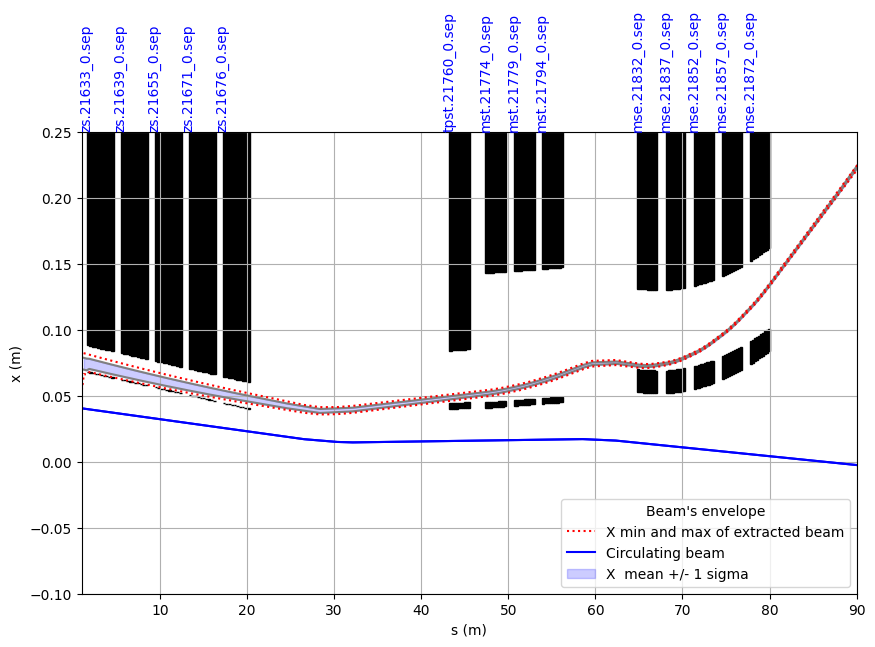

In [75]:
# Drawing the elements
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_ylim(-0.1, 0.25)
ax.set_xlim(1, 90)
draw_sep_elements(ax, LSS2)

up_beam_position = x_means + x_stds
down_beam_position = x_means - x_stds

max_beam_position = x_means + 3 * x_stds
min_beam_position = x_means - 3 * x_stds 

ax.plot(s_positions_monitors, down_beam_position, color = 'grey', linestyle='-')
ax.plot(s_positions_monitors, up_beam_position, color = 'grey', linestyle='-')
#ax.plot(s_positions_monitors, max_beam_position, color = 'grey', linestyle='-')
#ax.plot(s_positions_monitors, min_beam_position, color = 'grey', linestyle='-')

ax.plot(x_min, color = 'red', linestyle=':', label = 'X min and max of extracted beam')
ax.plot(x_max,  color = 'red', linestyle=':')

ax.plot(x_minInitial, color = 'blue', linestyle='-', label = 'Circulating beam')
ax.plot(x_maxInitial,  color = 'blue', linestyle='-')

ax.grid(True)

ax.fill_between(s_positions_monitors,  down_beam_position, up_beam_position, color='blue', alpha=0.2, label = 'X  mean +/- 1 sigma')
#ax.fill_between(s_positions_monitors,  max_beam_position, min_beam_position, color='red', alpha=0.2, label = 'X  mean +/- 3 sigma')

ax.legend(title = "Beam's envelope", loc =  'lower right')



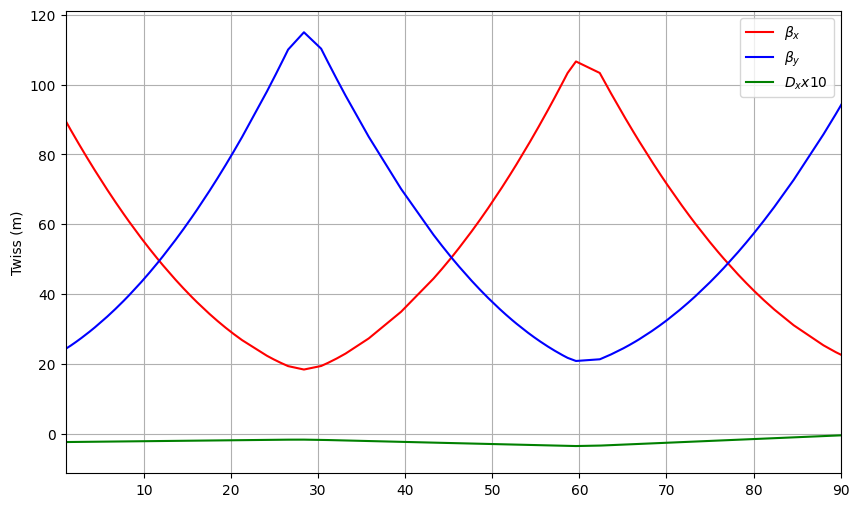

In [76]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.set_ylabel(r'Twiss (m)')
ax2.plot(twissDF['s'], twissDF['betx'], 'r-', label=r'$\beta_x$')
ax2.plot(twissDF['s'], twissDF['bety'], 'b-', label=r'$\beta_y$')
ax2.plot(twissDF['s'], twissDF['dx']*10, 'g-', label=r'$D_x x10$')
ax2.set_xlim(1, 90)
ax2.legend(loc='upper right')
plt.grid(True)


Element: zs.21633_0.sep, s_position: 1.565, blade_position: 0.068, thickness: 6e-05
Element: zs.21633_1.sep, s_position: 1.8749999999999454, blade_position: 0.06753350000000001, thickness: 6e-05
Element: zs.21633_2.sep, s_position: 2.184999999999891, blade_position: 0.067067, thickness: 6e-05
Element: zs.21633_3.sep, s_position: 2.4950000000000636, blade_position: 0.0666005, thickness: 6e-05
Element: zs.21633_4.sep, s_position: 2.805000000000009, blade_position: 0.066134, thickness: 6e-05
Element: zs.21633_5.sep, s_position: 3.1149999999999545, blade_position: 0.0656675, thickness: 6e-05
Element: zs.21633_6.sep, s_position: 3.4249999999998453, blade_position: 0.06520100000000001, thickness: 6e-05
Element: zs.21633_7.sep, s_position: 3.735000000000018, blade_position: 0.0647345, thickness: 6e-05
Element: zs.21633_8.sep, s_position: 4.0449999999999635, blade_position: 0.064268, thickness: 6e-05
Element: zs.21633_9.sep, s_position: 4.354999999999909, blade_position: 0.06380150000000001, t

/var/folders/vc/njn3rgb96cq7_32jmcfzppkm0000gn/T/ipykernel_62570/523123035.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right')


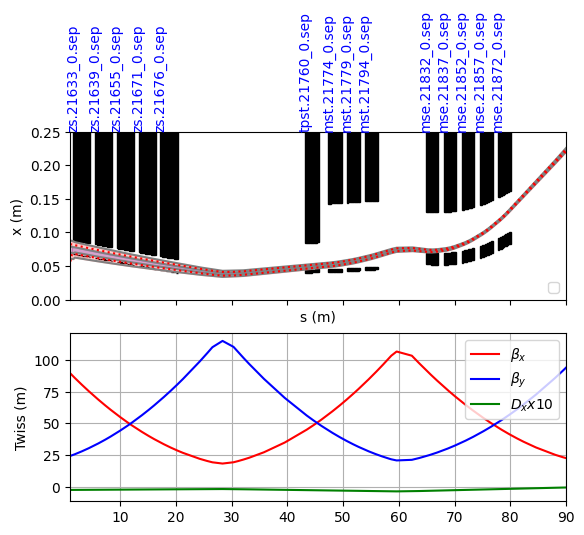

In [77]:
# Drawing the elements
#fig, (ax, ax2) = plt.subplots(figsize=(10, 6))
fig, (ax, ax2) = plt.subplots(2, 1, sharex=True)

ax.set_ylim(0.0, 0.25)
ax.set_xlim(1, 90)
draw_sep_elements(ax, LSS2)

up_beam_position = x_means + x_stds
down_beam_position = x_means - x_stds

max_beam_position = x_means + 3 * x_stds
min_beam_position = x_means - 3 * x_stds 

ax.plot(s_positions_monitors, down_beam_position, color = 'grey', linestyle='-')
ax.plot(s_positions_monitors, up_beam_position, color = 'grey', linestyle='-')
ax.plot(s_positions_monitors, max_beam_position, color = 'grey', linestyle='-')
ax.plot(s_positions_monitors, min_beam_position, color = 'grey', linestyle='-')

ax.plot(x_min, color = 'red', linestyle=':', label = 'X min and max')
ax.plot(x_max,  color = 'red', linestyle=':')

ax.fill_between(s_positions_monitors,  down_beam_position, up_beam_position, color='blue', alpha=0.2, label = 'X  mean +/- 1 sigma')
ax.fill_between(s_positions_monitors,  max_beam_position, min_beam_position, color='red', alpha=0.2, label = 'X  mean +/- 3 sigma')

#ax.legend(title = "Beam's envelope")


ax2.set_ylabel(r'Twiss (m)')
ax2.plot(twissDF['s'], twissDF['betx'], 'r-', label=r'$\beta_x$')
ax2.plot(twissDF['s'], twissDF['bety'], 'b-', label=r'$\beta_y$')
ax2.plot(twissDF['s'], twissDF['dx']*10, 'g-', label=r'$D_x x10$')
ax2.set_xlim(1, 90)
ax2.legend(loc='upper right')
plt.grid(True)


In [78]:
LSS2.get_table().show()

name                                                 s element_type         isthick isreplica ...
zs.21633_entry                                       0 Marker                 False     False
drift_zs.21633..1..0                                 0 DriftSlice              True     False
ZSEntry.monitor                                 1.2581 BeamSizeMonitor        False     False
drift_zs.21633..1..1                            1.2581 DriftSlice              True     False
zs.21633_0.monitor                               1.565 BeamSizeMonitor        False     False
zs.21633_0.sep                                   1.565 BeamInteraction        False     False
zs.21633                                         1.565 Multipole              False     False
drift_zs.21633..2..0                             1.565 DriftSlice              True     False
zs.21633_1.monitor                               1.875 BeamSizeMonitor        False     False
zs.21633_1.sep                                   1.875 B